## Introduction
For Armenians, April 24 is a fixed point in time. It marks Armenian Genocide Remembrance Day, a date that is commemorated every year.

But I wanted to understand what this moment looks like outside of the community.

Does the rest of the world pay attention to the Armenian Genocide consistently, or only at specific moments?

To explore this, I used Google Trends data as a proxy for public interest and compared it to social media activity on Twitter.

![](arm.png){width=800}

## Data 

### Google Trends

I used Google Trends data for the search term:

“Armenian genocide”

Google Trends reports data on a scale from 0 to 100, where 100 represents the highest level of search interest within the selected time period. This means the data captures changes in attention over time rather than total search volume. One challenge when working with Google Trends is that the data is normalized within the selected time range. If multiple years are pulled together at once, smaller spikes can become compressed relative to the largest peak.

Instead of using a single multi-year dataset, I worked with yearly exports that were combined together. To address this, I collected Google Trends data separately for each year and then combined the results. This makes it easier to compare yearly patterns and observe differences in the magnitude of spikes over time.


## Twitter Data
To measure public expression, I use a dataset of tweets containing the hashtag:

#1915neveragain

This dataset comes from a historical Twitter archive that represents about 1% of all tweets. While not complete, it provides a useful sample of how people publicly engage with the topic over time.

### Methods

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/gtrends_armenian_genocide.csv')

df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year

To understand how attention changes within each year, I plotted search interest separately for every year.

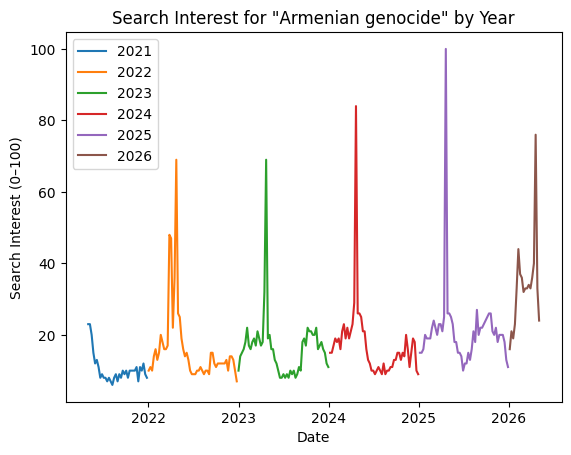

In [33]:
for year in sorted(df['year'].unique()):
    subset = df[df['year'] == year]
    plt.plot(subset['date'], subset['Armenian genocide'], label=year)

plt.legend()
plt.title('Search Interest for "Armenian genocide" by Year')
plt.xlabel('Date')
plt.ylabel('Search Interest (0–100)')
plt.show()

Next, I processed the Twitter data by grouping tweets by date and counting how many occurred each day.

In [34]:
twitter_df = pd.read_csv('data/twitter_sample_#1915neveragain.csv')

twitter_df['date'] = pd.to_datetime(twitter_df['created_at']).dt.date
daily_counts = twitter_df.groupby('date').size()

/tmp/ipykernel_886538/2578772940.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  twitter_df['date'] = pd.to_datetime(twitter_df['created_at']).dt.date


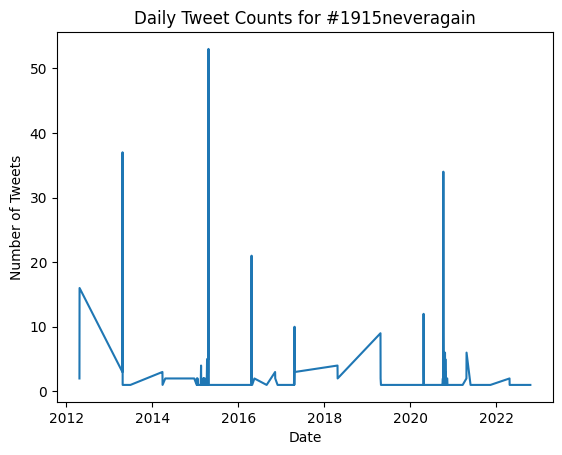

In [35]:
daily_counts.plot()
plt.title('Daily Tweet Counts for #1915neveragain')
plt.xlabel('Date')
plt.ylabel('Number of Tweets')
plt.show()

## What the Data Shows

The Google Trends data reveals a very clear pattern.

For most of the year, search interest in “Armenian genocide” stays relatively low. But every year, there is a sharp and sudden spike in April.

These spikes occur at almost the exact same time each year, aligning with April 24. The pattern is consistent across all years, suggesting that public attention is strongly tied to this specific date.

What stands out even more is how concentrated the attention is. Interest rises quickly, peaks, and then drops off just as fast. This suggests that attention is not sustained over time, but instead triggered by a specific annual event.

At the same time, the size of the spikes varies. Some years show much higher peaks than others. For example, 2025 reaches the highest level of search interest, while earlier years show smaller increases. This indicates that certain years generate more attention, likely due to milestone anniversaries or increased media coverage.

## Comparing to Twitter

The Twitter data shows a similar but more uneven pattern.

There are visible increases in tweet activity around April 24, suggesting that people are not only searching for information, but also expressing themselves publicly during this time.

However, the pattern is much less smooth than Google Trends. This is partly because the dataset is a small sample (1% of tweets) and relies on a specific hashtag. As a result, the data is more sparse and does not capture all forms of conversation.

This highlights an important difference:

- Google Trends captures private information-seeking behavior
- Twitter captures public expression, but only partially

## Interpretation

Taken together, these datasets show that attention to the Armenian Genocide is not constant.

Instead, it is highly time-bound and event-driven.

Every year, April 24 acts as a trigger that brings the topic into public awareness. Outside of this period, interest drops significantly.

At the same time, the intensity of attention varies. Larger spikes in certain years suggest that historical milestones and external events can amplify visibility.

## Limitations

There are a few important limitations to consider:

- Google Trends data is relative, not absolute
- The Twitter dataset represents only a small sample of tweets
- The hashtag #1915neveragain does not capture all relevant discussion
- Search data does not tell us why people are searching

## Conclusion
This analysis shows that public attention to the Armenian Genocide is not evenly distributed over time.

Instead, it is concentrated around April 24, when both search activity and public expression increase significantly.

By combining Google Trends and Twitter data, we can see how attention emerges in different forms — through both private curiosity and public commemoration — and how that attention is shaped by time, memory, and historical context.

![](mamdani.png){width=800}